### **Classification de sentiments sur des critiques de films**

## 1. Setup

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

from src.transformer_modules.transformer_modules import *
from src.modeles.transformer_classifier import TransformerClassifier
import urllib.request
import tarfile
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset


## 2. Configuration

In [9]:
import random
import numpy as np

SEED = 42
BATCH_SIZE = 32
MAX_LEN = 512
EPOCHS = 10
LR = 3e-4
WEIGHT_DECAY = 1e-2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


## 3. Donnees

### Chargement des donnees

Il s'agit d'un jeu de donnees pour la classification binaire des sentiments. Il y a 25 000 critiques de films tres polarisees pour l'entrainement et 25 000 pour les tests.

In [10]:
url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
output = DATA_DIR / "aclImdb_v1.tar.gz"

if not output.exists():
    urllib.request.urlretrieve(url, str(output))

if not (DATA_DIR / "aclImdb").exists():
    with tarfile.open(output, "r:gz") as f:
        f.extractall(path=str(DATA_DIR))
    

### Preparation des donnees

In [ ]:
from src.utils.data import clean_text, create_vocab, load_and_prepare_imdb
from src.utils.train_and_evaluate import create_padding_mask

In [12]:
# preparation des donnees de train
max_len = MAX_LEN
X_train, y_train, vocab = load_and_prepare_imdb(
      str(DATA_DIR / "aclImdb" / "train"),
      vocab=None, 
      max_len=max_len
)

# Création des DataLoaders
batch_size = BATCH_SIZE
train_dataset = TensorDataset(X_train, y_train.float())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Preparation des données de validation et de test
X_val_all, y_val_all, _ = load_and_prepare_imdb(str(DATA_DIR / "aclImdb" / "test"), vocab=vocab)
X_val, X_test, y_val, y_test = train_test_split(
        X_val_all,
        y_val_all,
        test_size=0.2, 
        random_state=142,
        stratify=y_val_all
)

val_dataset = TensorDataset(X_val, y_val.float())
test_dataset = TensorDataset(X_test, y_test.float()) 

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [13]:
X_train.shape, y_train.shape,  X_test.shape, y_test.shape, X_val.shape, y_val.shape

(torch.Size([25000, 512]),
 torch.Size([25000]),
 torch.Size([5000, 256]),
 torch.Size([5000]),
 torch.Size([20000, 256]),
 torch.Size([20000]))

In [14]:
#  Configuration du device (CPU ou GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 4. Entrainement et evaluation

In [16]:
import torch.optim as optim
from torch.nn import BCEWithLogitsLoss

from src.utils.train_and_evaluate import (
    collect_predictions,
    evaluate,
    run_model_and_collect,
    test_metrics_with_time,
    train,
    train_model,
)


## 5. Modeles

### Transformer

In [17]:
results = []
histories = {}
criterion = torch.nn.BCEWithLogitsLoss()
epochs = EPOCHS

In [ ]:
# Initialisation du modèle avec hyperparamètres raisonnables
# Note: Vous pouvez ajuster ces hyperparamètres en fonction de vos ressources et de vos besoins

d_model = 512      # Dimension des embeddings
N = 6              # 6 blocs encodeurs
h = 8              # 8 têtes d'attention
d_ff = 4 * d_model # Dimension feed-forward
dropout = 0.5      # Dropout pour régularisation

transformer = TransformerEncoderModel(
    vocab_size=len(vocab),
    d_model=d_model,      
    N=N,             
    h=h,              
    d_ff=d_ff,         
    dropout=dropout       
).to(device)


transformer_model = TransformerClassifier(
    transformer, 
    d_model=512, 
    num_classes=1, 
    pool_strategy="mean", 
    dropout=0.5
).to(device)

print(f"Nombre de paramètres: {sum(p.numel() for p in transformer_model.parameters()):,}")

opt_tr = torch.optim.AdamW(transformer_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
summary, history = run_model_and_collect(
    transformer_model, "Transformer",
    train_loader, val_loader, test_loader,
    opt_tr, criterion, device,
    epochs=epochs, use_mask=True
)
results.append(summary)
histories["Transformer"] = history

### GRU

In [ ]:
from src.modeles.rnn_classifier import RNNClassifier

embeding_dim = 512 # Dimension des embeddings
hidden_dim = 128 # Dimension des états cachés
num_layers = 3 # Nombre de couches
bidirectional = True # Utilisation d'un RNN bidirectionnel
dropout = 0.5 # Taux de dropout

gru_model = RNNClassifier(
    vocab_size = len(vocab),
    embed_dim = embeding_dim,
    hidden_dim = hidden_dim,
    num_layers = num_layers,
    bidirectional = bidirectional,
    dropout = dropout,
    pad_idx = 0,
    rnn_type = "gru"
).to(device)

print(f"Nombre de paramètres: {sum(p.numel() for p in gru_model.parameters()):,}")
#train_model(gru_model,train_loader,test_loader,optimizer=None,criterion=None,device=device,epochs=10)

opt_gru = torch.optim.AdamW(gru_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
summary, history = run_model_and_collect(
    gru_model, "GRU",
    train_loader, val_loader, test_loader,
    opt_gru, criterion, device,
    epochs=epochs, use_mask=True
)
results.append(summary)
histories["GRU"] = history

### LSTM

In [ ]:
lstm_model = RNNClassifier(
    vocab_size = len(vocab),
    embed_dim = embeding_dim,
    hidden_dim = hidden_dim,
    num_layers = num_layers,
    bidirectional = bidirectional,
    dropout = dropout,
    pad_idx = 0,
    rnn_type = "lstm"
).to(device)

print(f"Nombre de paramètres LSTM: {sum(p.numel() for p in lstm_model.parameters()):,}")

#train_model(gru_model, train_loader, test_loader, None, None, device, epochs=10)

opt_lstm = torch.optim.AdamW(lstm_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
summary, history = run_model_and_collect(
    lstm_model, "LSTM",
    train_loader, val_loader, test_loader,
    opt_lstm, criterion, device,
    epochs=epochs, use_mask=True
)
results.append(summary)
histories["LSTM"] = history

### CNN

In [ ]:
from src.modeles.cnn_classifier import TextCNNClassifier

cnn_model = TextCNNClassifier(
    vocab_size=len(vocab),
    embed_dim=embeding_dim,
    kernel_sizes=[3,4,5],
    num_filters=100,
    dropout=dropout,
    pad_idx=0
).to(device)

print(f"Nombre de paramètres CNN: {sum(p.numel() for p in cnn_model.parameters()):,}")

#train_model(cnn_model, train_loader, test_loader, None, None, device, epochs=10)

opt_cnn = torch.optim.AdamW(cnn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
summary, history = run_model_and_collect(
    cnn_model, "TextCNN",
    train_loader, val_loader, test_loader,
    optimizer=opt_cnn,
    criterion=criterion,
    device=device,
    epochs=epochs,
    use_mask=False
)
results.append(summary)
histories["TextCNN"] = history

## 6. Resultats

### Tableau recapitulatif

In [ ]:
import pandas as pd
df = pd.DataFrame(results)
df

### Courbes d'apprentissage

/tmp/ipykernel_11752/2914065233.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


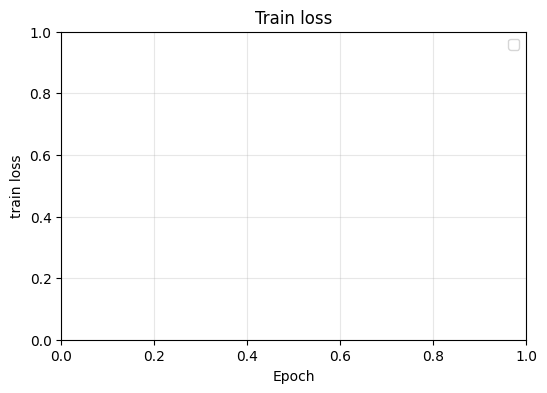

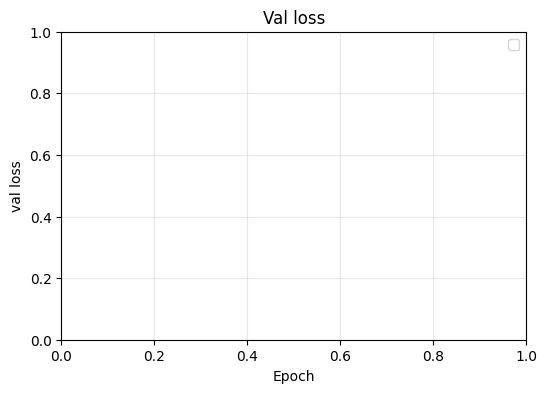

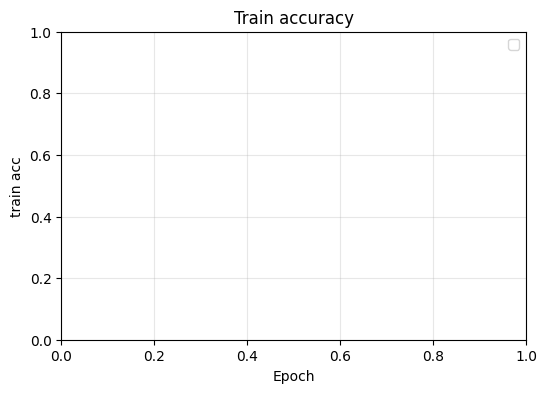

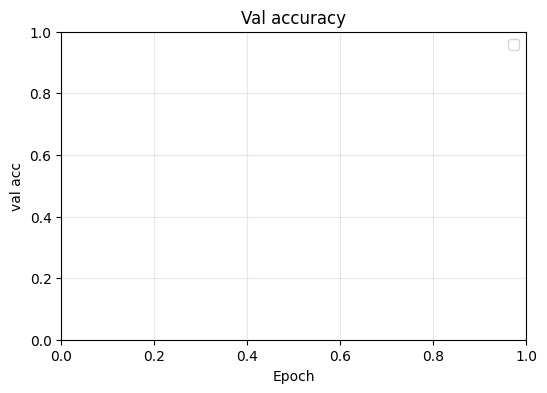

In [21]:
import matplotlib.pyplot as plt

def plot_history(histories, metric, title):
    plt.figure(figsize=(6, 4))
    for name, hist in histories.items():
        plt.plot(hist[metric], label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " "))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_history(histories, "train_loss", "Train loss")
plot_history(histories, "val_loss", "Val loss")
plot_history(histories, "train_acc", "Train accuracy")
plot_history(histories, "val_acc", "Val accuracy")


### Courbes ROC et Precision-Recall

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, auc, confusion_matrix, precision_recall_curve, roc_curve

models_info = [
    ("Transformer", transformer_model, True),
    ("GRU", gru_model, True),
    ("LSTM", lstm_model, True),
    ("TextCNN", cnn_model, False),
]

preds = {}
for name, model, use_mask in models_info:
    y_true, y_prob, y_pred = collect_predictions(model, test_loader, device, use_mask=use_mask)
    preds[name] = {"y_true": y_true, "y_prob": y_prob, "y_pred": y_pred}

plt.figure(figsize=(6, 4))
for name, p in preds.items():
    fpr, tpr, _ = roc_curve(p["y_true"], p["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
for name, p in preds.items():
    precision, recall, _ = precision_recall_curve(p["y_true"], p["y_prob"])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.3f})")
plt.title("Precision-Recall curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


NameError: name 'transformer_model' is not defined

### Matrices de confusion

In [ ]:
for name, p in preds.items():
    cm = confusion_matrix(p["y_true"], p["y_pred"])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion matrix - {name}")
    plt.show()


## 7. Sauvegarde et chargement

In [ ]:
# Sauvegarder le modèle Transformer
torch.save(transformer_model.state_dict(), MODELS_DIR / "transformer_sentiment.pt")


In [ ]:
# Recharger le modèle 
model = TransformerClassifier(
    transformer, 
    d_model=d_model, 
    num_classes=1, 
    pool_strategy="mean", 
    dropout=dropout
).to(device)  
model.load_state_dict(torch.load(MODELS_DIR / "transformer_sentiment.pt", map_location="cpu"))
model.eval()
